Importing:

In [61]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Settting style and paths:

In [62]:
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR = Path("../data/processed") 

Loading data:

In [63]:
train = pd.read_csv(DATA_DIR / "train.csv")
val = pd.read_csv(DATA_DIR / "val.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("dataset sizes:")
print(f"train: {len(train):,} rows")
print(f"val: {len(val):,} rows")
print(f"test: {len(test):,} rows")



dataset sizes:
train: 35,364 rows
val: 7,660 rows
test: 15,990 rows


Basic Data Overview:

In [64]:
print("\n=== Train Set Info ===")
print(train.info())
print("\n=== Train Set Shape ===")
print(f"Rows: {train.shape[0]}, Columns: {train.shape[1]}")
print("\n=== First Few Rows ===")
train.head()
print("\n=== Column Names ===")
print(train.columns.tolist())


=== Train Set Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35364 entries, 0 to 35363
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  35364 non-null  int64  
 1   round                 35364 non-null  object 
 2   best_of               35364 non-null  int64  
 3   player_hand           35364 non-null  object 
 4   player_ht             35320 non-null  float64
 5   player_ioc            35364 non-null  object 
 6   player_age            35364 non-null  float64
 7   player_rank           35364 non-null  float64
 8   player_rank_points    35364 non-null  float64
 9   opponent_hand         35364 non-null  object 
 10  opponent_ht           35320 non-null  float64
 11  opponent_ioc          35364 non-null  object 
 12  opponent_age          35364 non-null  float64
 13  opponent_rank         35364 non-null  float64
 14  opponent_rank_points  35364 non-null  float64


Target Variable Analysis:


=== Label Distribution ===
label
1    17682
0    17682
Name: count, dtype: int64

Win rate (label=1): 50.00%


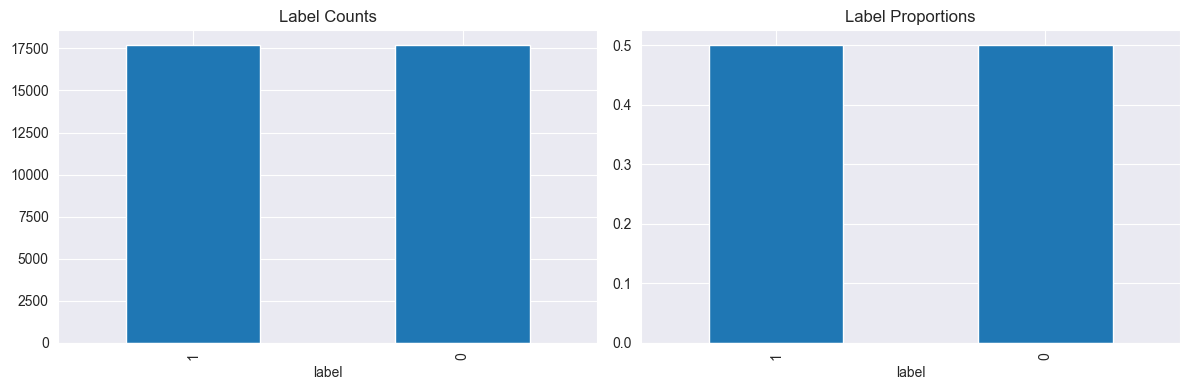

In [65]:
print("\n=== Label Distribution ===")
print(train['label'].value_counts())
print(f"\nWin rate (label=1): {train['label'].mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['label'].value_counts().plot(kind='bar', ax=axes[0], title='Label Counts')
train['label'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], title='Label Proportions')
plt.tight_layout()
plt.show()


Correlation Analysis:

Numeric features: ['year', 'best_of', 'player_ht', 'player_age', 'player_rank', 'player_rank_points', 'opponent_ht', 'opponent_age', 'opponent_rank', 'opponent_rank_points', 'month', 'rank_diff', 'age_diff', 'height_diff', 'rank_points_diff']


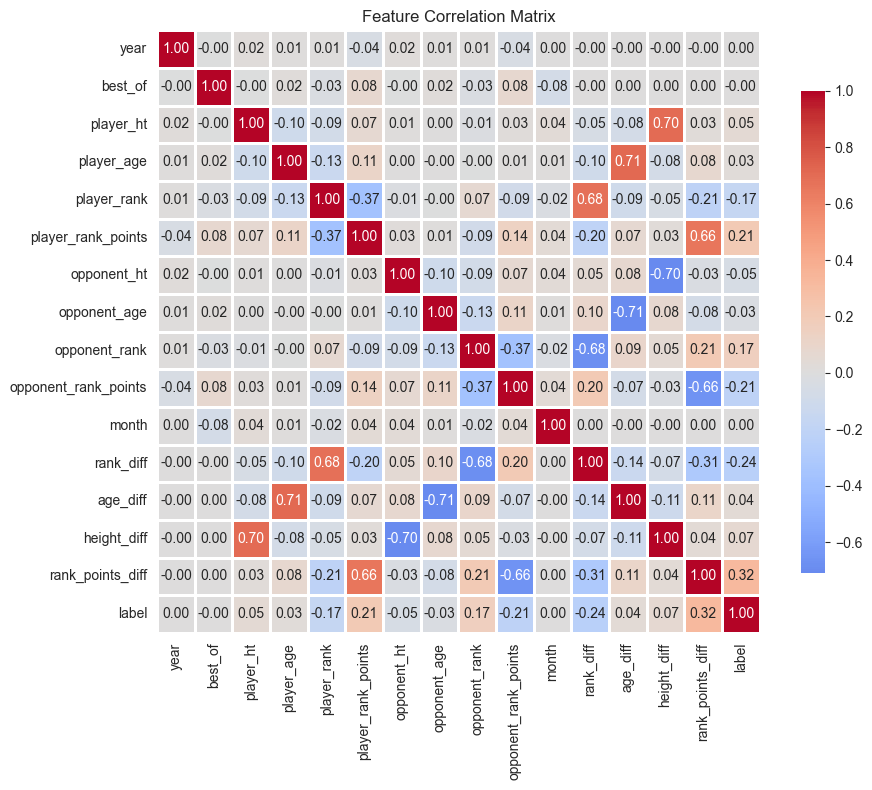


=== Correlation with Label ===
label                   1.000000e+00
rank_points_diff        3.243139e-01
player_rank_points      2.130378e-01
opponent_rank           1.663907e-01
height_diff             7.165168e-02
player_ht               5.044870e-02
age_diff                4.022777e-02
player_age              2.844827e-02
year                    8.559785e-15
month                   1.156277e-15
best_of                -1.472538e-17
opponent_age           -2.844827e-02
opponent_ht            -5.044870e-02
player_rank            -1.663907e-01
opponent_rank_points   -2.130378e-01
rank_diff              -2.436186e-01
Name: label, dtype: float64


In [66]:

# Automatically select numeric columns (exclude boolean one-hot encoded)
numeric_features = train.select_dtypes(include=[np.number]).columns.tolist()
# Remove 'label' from the list if you want to add it separately
numeric_features = [col for col in numeric_features if col != 'label']

print(f"Numeric features: {numeric_features}")
# Correlation matrix
corr_matrix = train[numeric_features + ['label']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Correlation with target
print("\n=== Correlation with Label ===")
correlations = train[numeric_features + ['label']].corr()['label'].sort_values(ascending=False)
print(correlations)

Categorical Features Analysis:


=== Categorical Features (One-hot encoded) ===
Number of categorical features: 6
['surface_Grass', 'surface_Hard', 'tourney_level_F', 'tourney_level_G', 'tourney_level_M', 'tourney_level_O']


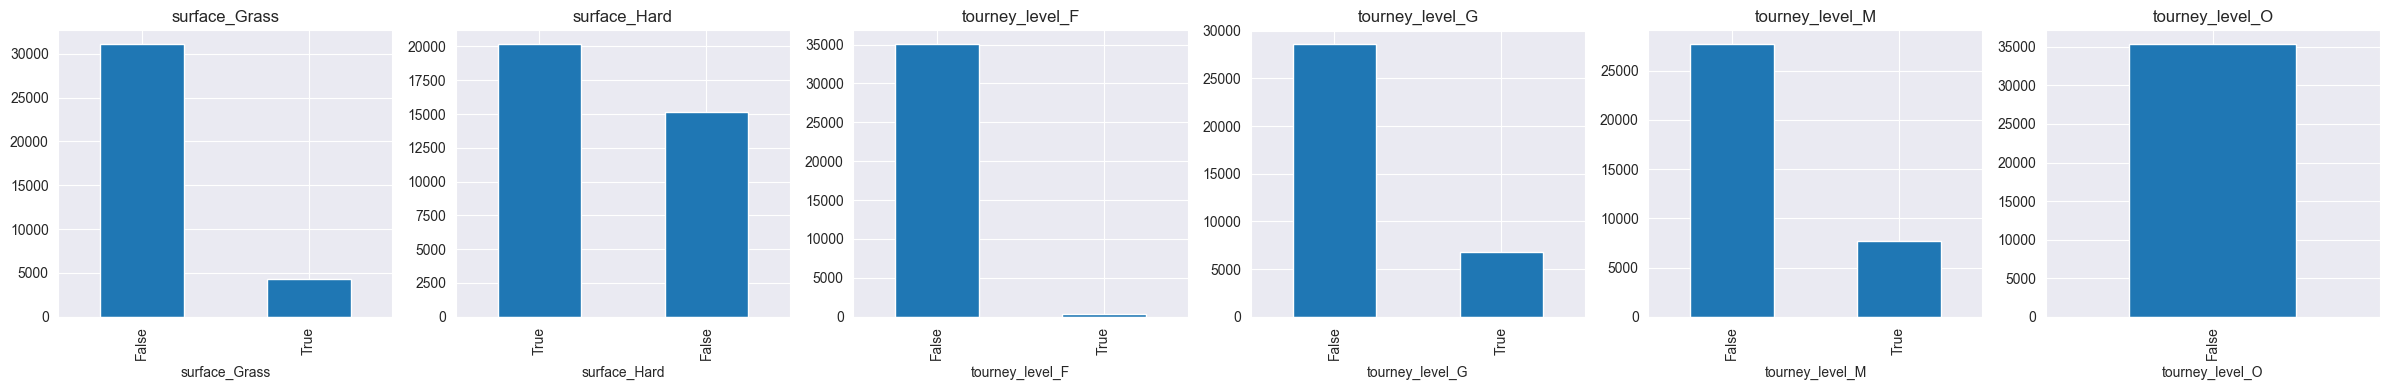

In [67]:
# Check one-hot encoded features
categorical_features = [col for col in train.columns if col.startswith(('surface_', 'tourney_level_'))]
print(f"\n=== Categorical Features (One-hot encoded) ===")
print(f"Number of categorical features: {len(categorical_features)}")
print(categorical_features)

# Distribution of categorical features
if categorical_features:
    fig, axes = plt.subplots(1, len(categorical_features), figsize=(4*len(categorical_features), 4))
    if len(categorical_features) == 1:
        axes = [axes]
    for i, col in enumerate(categorical_features):
        train[col].value_counts().plot(kind='bar', ax=axes[i], title=col)
    plt.tight_layout()
    plt.show()


Time-based Analysis:


=== Year Distribution ===
year
2013    5018
2014    4816
2015    5036
2016    5162
2017    5100
2018    5310
2019    4922
Name: count, dtype: int64


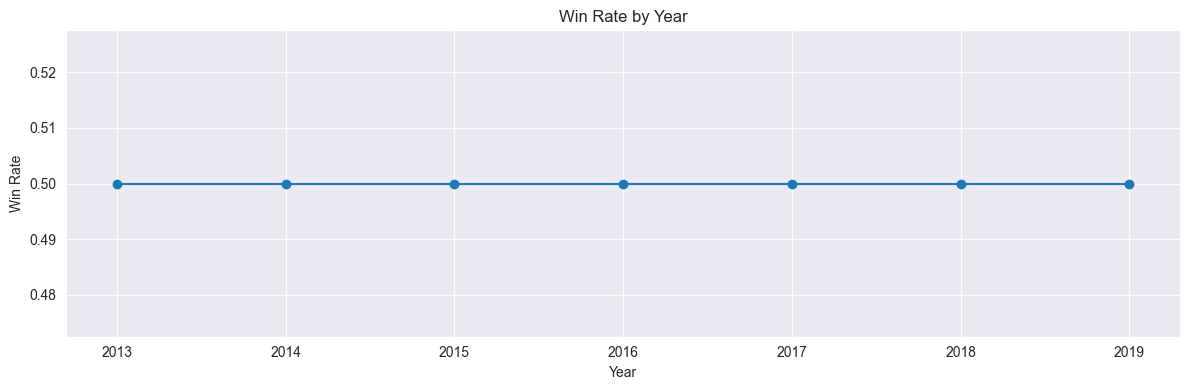


=== Month Distribution ===
month
1     3072
2     4624
3     2554
4     3294
5     4080
6     3130
7     4396
8     4030
9     1804
10    3672
11     392
12     316
Name: count, dtype: int64


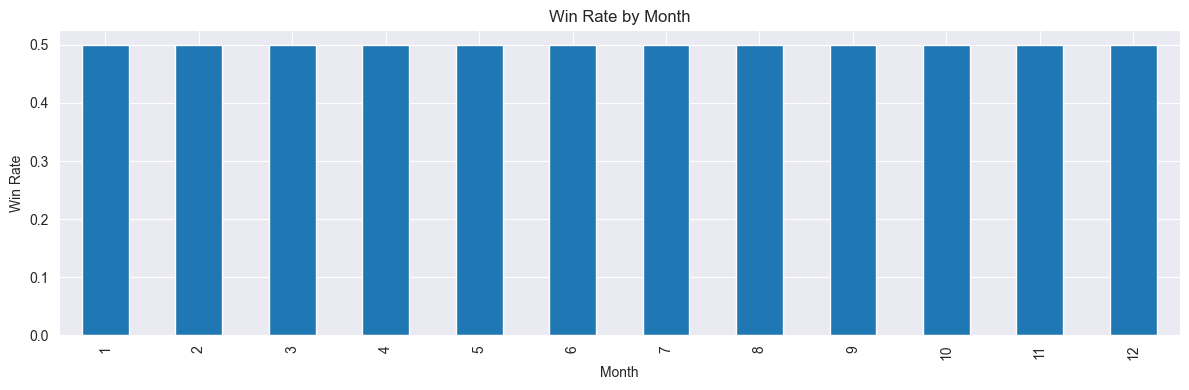

In [68]:
print("\n=== Year Distribution ===")
print(train['year'].value_counts().sort_index())

# Win rate by year
win_rate_by_year = train.groupby('year')['label'].mean()
plt.figure(figsize=(12, 4))
win_rate_by_year.plot(kind='line', marker='o')
plt.title('Win Rate by Year')
plt.xlabel('Year')
plt.ylabel('Win Rate')
plt.grid(True)
plt.tight_layout()
plt.show()

# Month analysis
if 'month' in train.columns:
    print("\n=== Month Distribution ===")
    print(train['month'].value_counts().sort_index())
    
    win_rate_by_month = train.groupby('month')['label'].mean()
    plt.figure(figsize=(12, 4))
    win_rate_by_month.plot(kind='bar')
    plt.title('Win Rate by Month')
    plt.xlabel('Month')
    plt.ylabel('Win Rate')
    plt.tight_layout()
    plt.show()

Ranking Analysis:

/var/folders/t3/6dbtzyqs1ld4lh3f0jqgbjnc0000gn/T/ipykernel_40864/1933325554.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate_by_rank_diff = train.groupby('rank_diff_binned')['label'].mean()


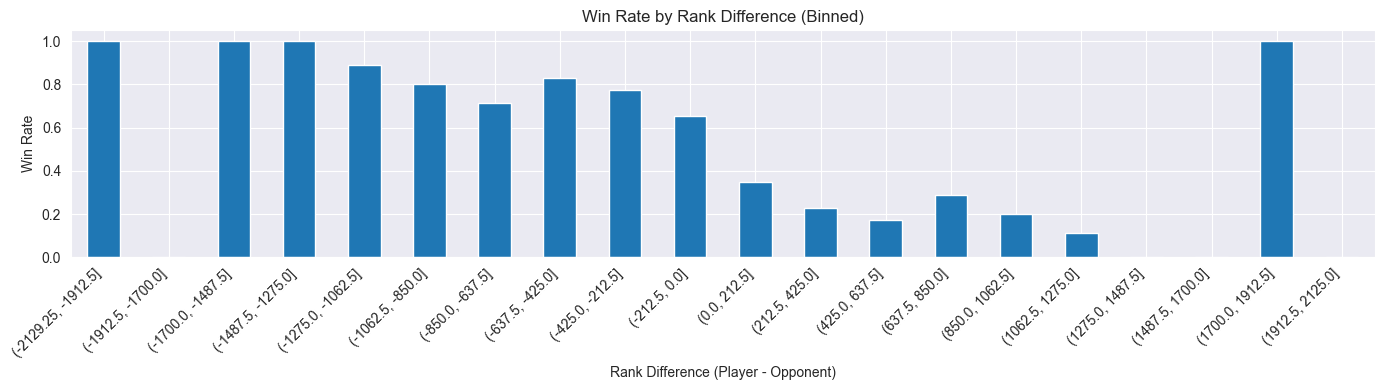

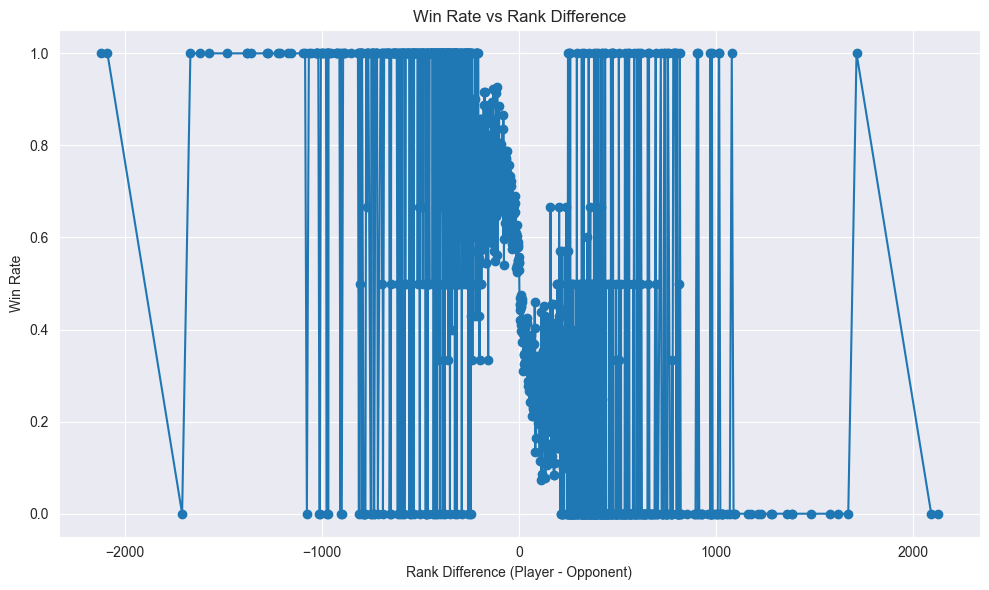

In [69]:
# Win rate by rank difference
train['rank_diff_binned'] = pd.cut(train['rank_diff'], bins=20)
win_rate_by_rank_diff = train.groupby('rank_diff_binned')['label'].mean()

plt.figure(figsize=(14, 4))
win_rate_by_rank_diff.plot(kind='bar')
plt.title('Win Rate by Rank Difference (Binned)')
plt.xlabel('Rank Difference (Player - Opponent)')
plt.ylabel('Win Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Scatter: rank_diff vs win rate
plt.figure(figsize=(10, 6))
train.groupby('rank_diff')['label'].mean().plot(kind='line', marker='o')
plt.title('Win Rate vs Rank Difference')
plt.xlabel('Rank Difference (Player - Opponent)')
plt.ylabel('Win Rate')
plt.grid(True)
plt.tight_layout()

Missing Data Check:

In [70]:
print("\n=== Missing Data ===")
missing = train.isnull().sum()
missing_pct = (missing / len(train)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing data!")


=== Missing Data ===
             Missing Count  Missing %
height_diff             88   0.248841
player_ht               44   0.124420
opponent_ht             44   0.124420


11. TRAIN/VAL/TEST COMPARISON


=== Dataset Comparison ===
            Train     Val     Test
Size      35364.0  7660.0  15990.0
Win Rate      0.5     0.5      0.5


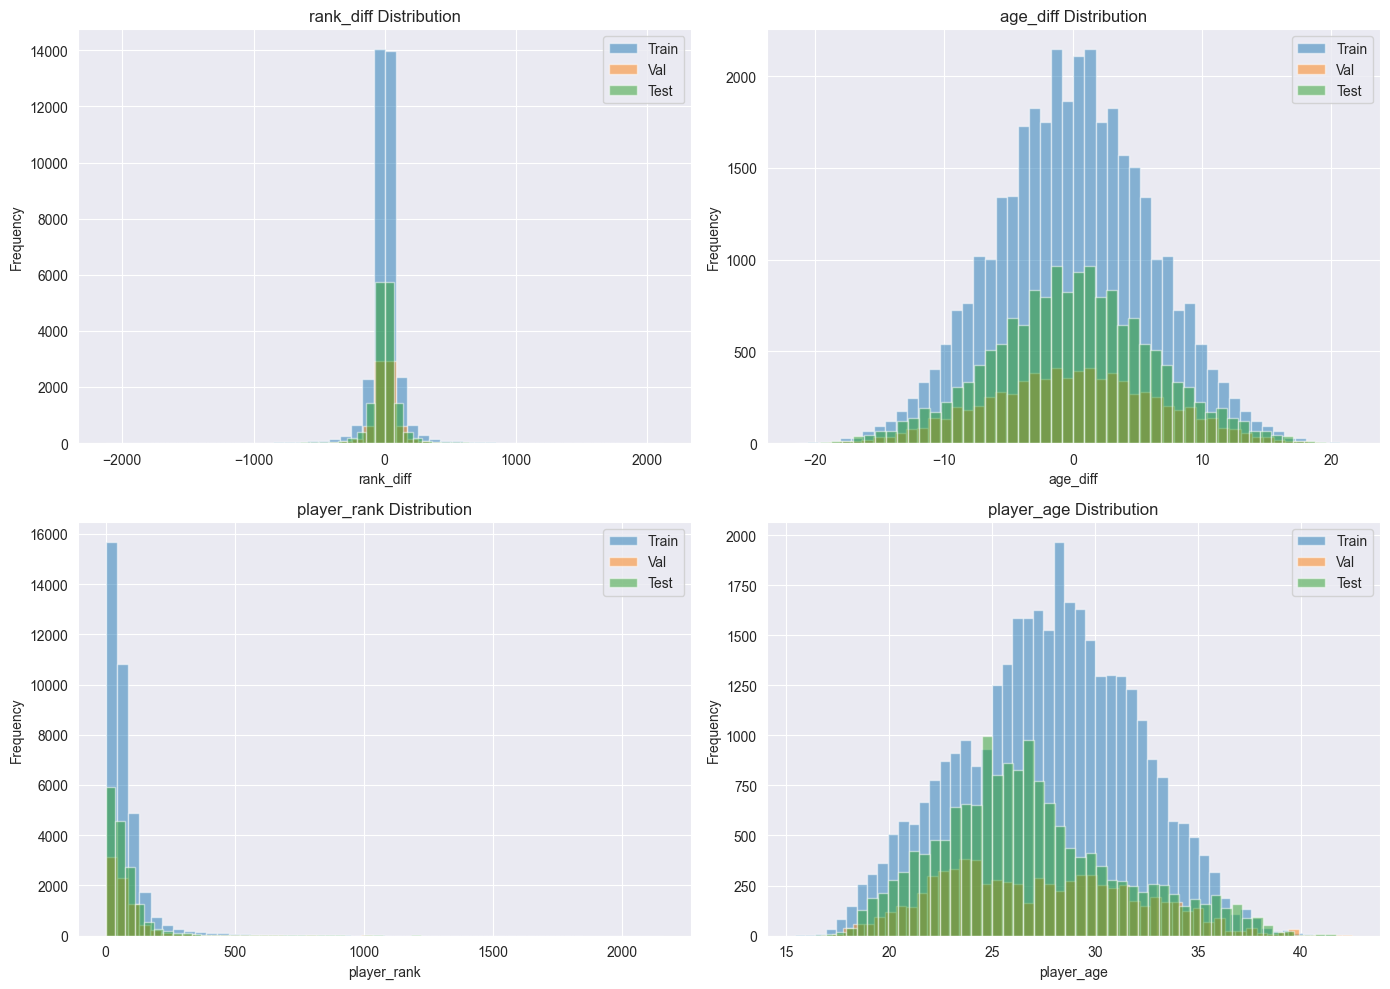

In [71]:
print("\n=== Dataset Comparison ===")
comparison = pd.DataFrame({
    'Train': [len(train), train['label'].mean()],
    'Val': [len(val), val['label'].mean()],
    'Test': [len(test), test['label'].mean()]
}, index=['Size', 'Win Rate'])
print(comparison)

# Feature distribution comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feature in enumerate(['rank_diff', 'age_diff', 'player_rank', 'player_age']):
    ax = axes[i // 2, i % 2]
    train[feature].hist(alpha=0.5, label='Train', bins=50, ax=ax)
    val[feature].hist(alpha=0.5, label='Val', bins=50, ax=ax)
    test[feature].hist(alpha=0.5, label='Test', bins=50, ax=ax)
    ax.set_title(f'{feature} Distribution')
    ax.legend()
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Key Insights & Summary

In [72]:
print("\n=== Key Insights ===")
print(f"1. Dataset is {'balanced' if 0.45 < train['label'].mean() < 0.55 else 'imbalanced'}")
print(f"2. Strongest correlation with label: {correlations.abs().nlargest(2).index[0] if len(correlations) > 1 else 'N/A'}")
print(f"3. Rank difference range: {train['rank_diff'].min():.0f} to {train['rank_diff'].max():.0f}")
print(f"4. Age difference range: {train['age_diff'].min():.1f} to {train['age_diff'].max():.1f}")


=== Key Insights ===
1. Dataset is balanced
2. Strongest correlation with label: label
3. Rank difference range: -2125 to 2125
4. Age difference range: -21.5 to 21.5
